In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
import numpy as np

In [3]:
features = pd.read_csv("../datasets/elliptic_txs_features.csv", header=None)
edges = pd.read_csv("../datasets/elliptic_txs_edgelist.csv")
classes = pd.read_csv("../datasets/elliptic_txs_classes.csv")

print("Features shape:", features.shape)
print("Classes shape:", classes.shape)
print("Edges shape:", edges.shape)

Features shape: (203769, 167)
Classes shape: (203769, 2)
Edges shape: (234355, 2)


In [4]:
features = features.rename(columns={0: "txId"})
data = features.merge(classes, on="txId")

data.head()

,txId,1,2,3,4,5,6,7,8,9,...,158,159,160,161,162,163,164,165,166,class
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,unknown
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,2
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117,unknown


In [5]:
data['class'] = data['class'].replace('unknown', -1)
data['class'] = data['class'].astype(int)
data['class'] = data['class'].replace({
    1:1,   # illicit
    2:0    # licit
})
data.head()

,txId,1,2,3,4,5,6,7,8,9,...,158,159,160,161,162,163,164,165,166,class
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,-1
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,-1
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,-1
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,0
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117,-1


In [6]:
class_counts = data["class"].value_counts()
class_counts

class
-1    157205
 0     42019
 1      4545
Name: count, dtype: int64

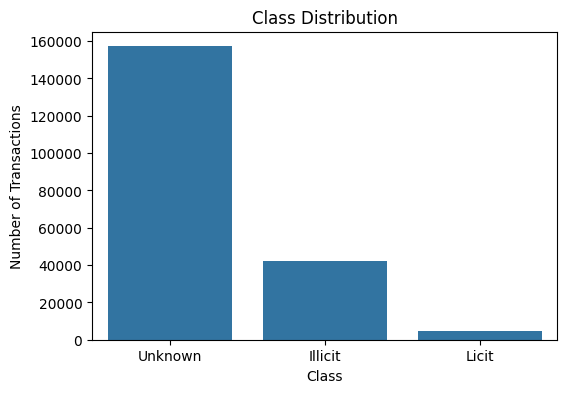

In [7]:
plt.figure(figsize=(6,4))
sns.barplot(x=class_counts.index, y=class_counts.values)

plt.xticks([0,1,2], ["Unknown","Illicit","Licit"])
plt.title("Class Distribution")
plt.ylabel("Number of Transactions")
plt.xlabel("Class")

plt.show()

In [8]:
data = data.rename(columns={1: "timestep"})

In [9]:
timestep_counts = data["timestep"].value_counts().sort_index()

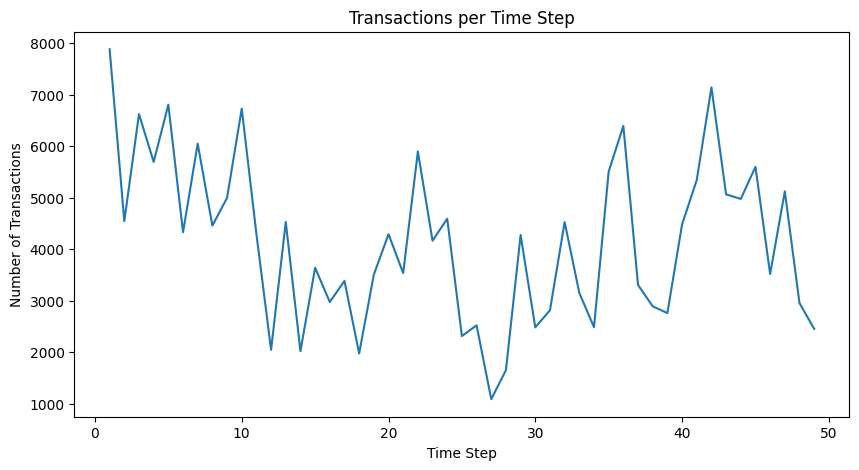

In [10]:
plt.figure(figsize=(10,5))

plt.plot(timestep_counts.index, timestep_counts.values)

plt.xlabel("Time Step")
plt.ylabel("Number of Transactions")
plt.title("Transactions per Time Step")

plt.show()

/var/folders/wm/0ft1r8fs2_b9my4l7wd__n300000gn/T/ipykernel_84341/2311000266.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


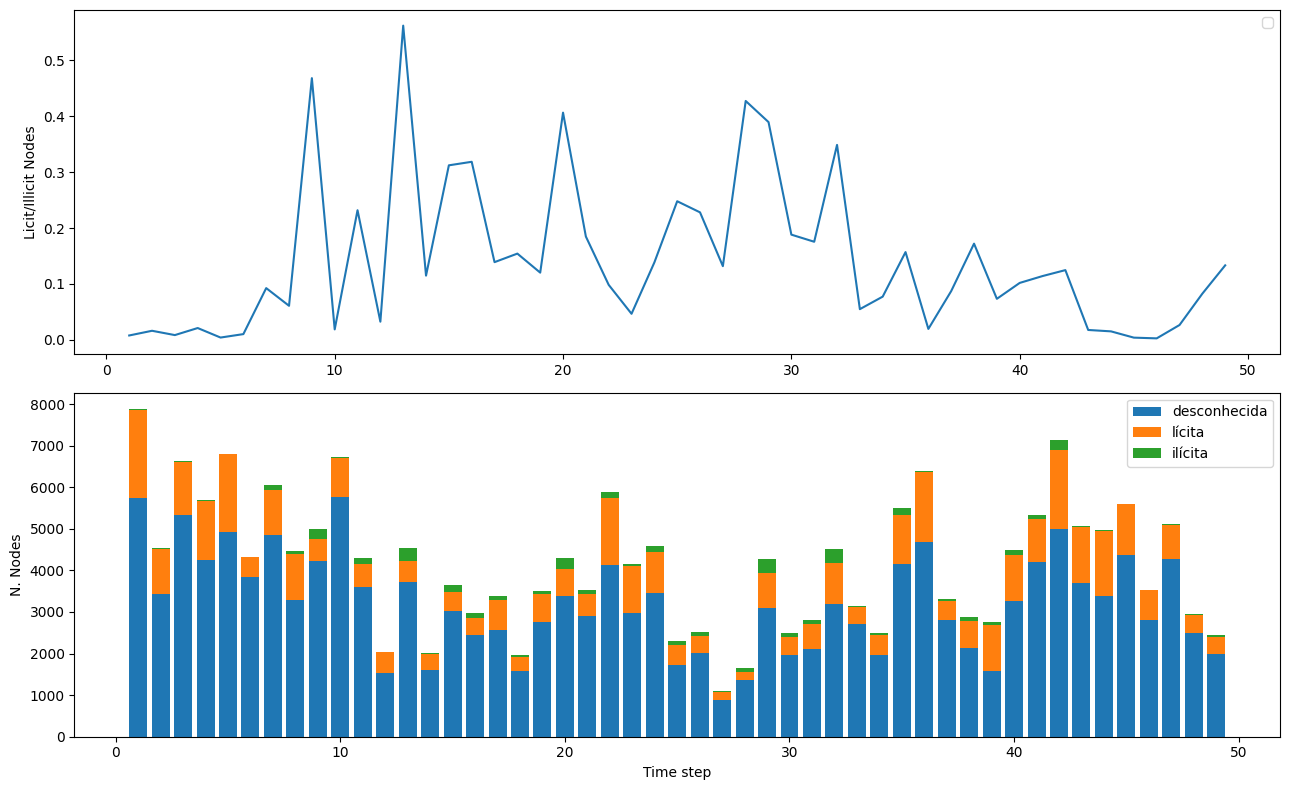

In [13]:

feat_cols = ['txId', 'time_step'] + [f'trans_feat_{i}' for i in range(93)] + [f'agg_feat_{i}' for i in range(72)]
feats = pd.read_csv("../datasets/elliptic_txs_features.csv", header=None, names=feat_cols)


classes.columns = ['txId', 'label']

df = classes.set_index('txId').join(feats.set_index('txId'))


total = df['time_step'].value_counts().sort_index()
illicit = df['time_step'][df['label']=='1'].value_counts().sort_index()
licit = df['time_step'][df['label']=='2'].value_counts().sort_index()
unknown = df['time_step'][df['label']=='unknown'].value_counts().sort_index()

step = np.arange(1, 50, dtype=int)

stacked = {
    "desconhecida":unknown,
    "lícita":licit,
    "ilícita":illicit  
}
width=0.8
bottom=np.zeros(49)
plt.figure(figsize=(13, 8), layout='tight')
plt.subplot(2, 1, 2)
for label, num in stacked.items():
    plt.bar(step, num, width, label=label, bottom=bottom)
    bottom += num
plt.legend()
plt.xlabel('Time step')
plt.ylabel('N. Nodes')
plt.subplot(2, 1, 1)
plt.plot(step, illicit/licit)
plt.legend()
plt.ylabel('Licit/Illicit Nodes')
plt.show()

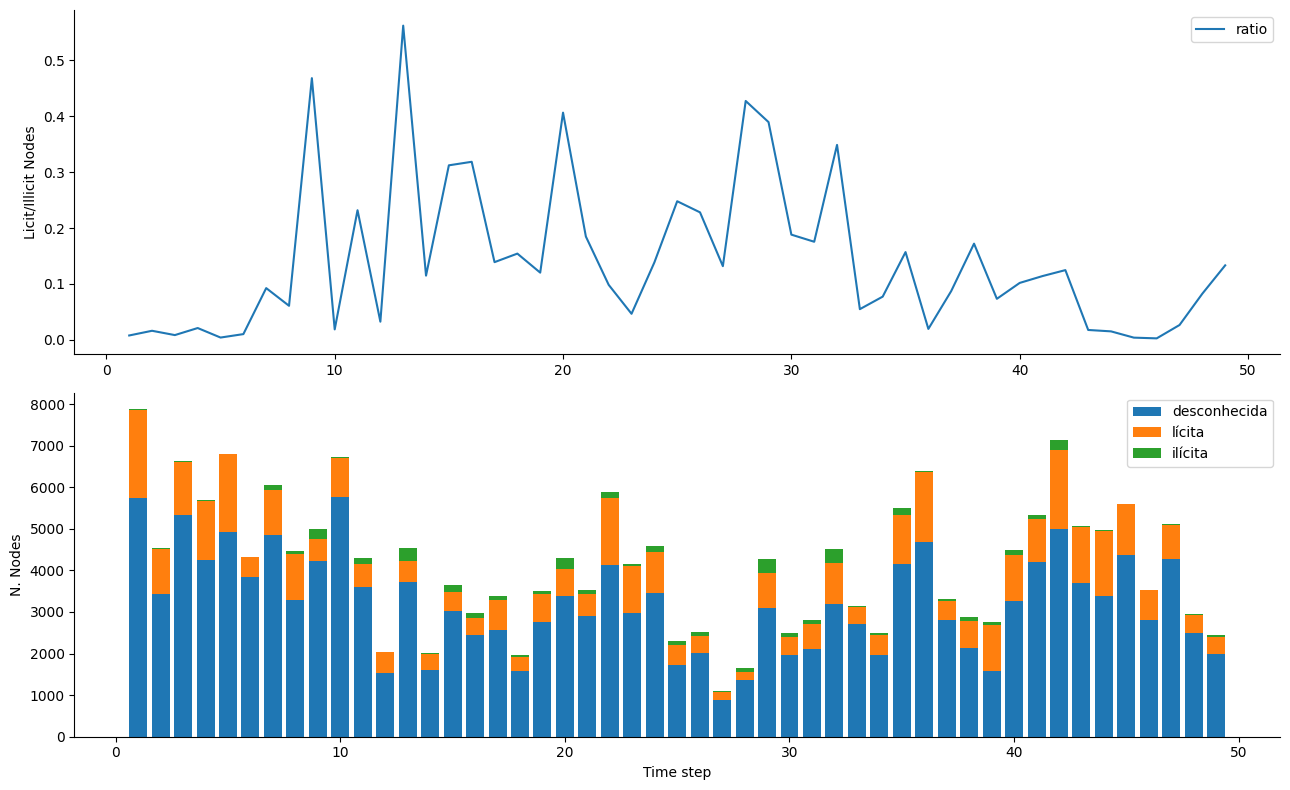

In [14]:
fig, axs = plt.subplots(2, 1, figsize=(13, 8), layout='tight')

# --- Gráfico de barras (embaixo)
ax = axs[1]
bottom = np.zeros(49)

for label, num in stacked.items():
    ax.bar(step, num, width, label=label, bottom=bottom)
    bottom += num

ax.legend()
ax.set_xlabel('Time step')
ax.set_ylabel('N. Nodes')

# Remove bordas superiores e direita
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# --- Gráfico de linha (em cima)
ax = axs[0]
ax.plot(step, illicit / licit, label='ratio')

ax.legend()
ax.set_ylabel('Licit/Illicit Nodes')

# Remove bordas superiores e direita
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.show()